<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Prepare the dataset

In [87]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [88]:
#load dataset
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

In [89]:
#remove unnecessary columns
df.drop(df.iloc[:,5:15], axis=1, inplace=True)

In [90]:
#rename column
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True)

In [91]:
#remove missing values
df2 = df.dropna().copy()

##2. Temperature vs Trout Presence (means/medians)

**Hypothesis**

- H0 (t-test): Mean temperature is equal between presence and absence

- H0 (Mann–Whitney): Distribution (median) is equal between groups

In [92]:
#split data
present = df2[df2["Salmo trutta fario"] == 1]["temp_ann"]
absent = df2[df2["Salmo trutta fario"] == 0]["temp_ann"]

In [93]:
#normality check
import scipy.stats as sts

stat, p_norm = sts.shapiro(df2["temp_ann"].sample(n=min(len(df2), 5000)))
print("Normality p-value:", p_norm)

Normality p-value: 2.93904182064672e-16


In [94]:
#homogeneity of variances check (Levene test)
stat, p_lev = sts.levene(present, absent, center='median')
print("Levene test p-value:", p_lev)

Levene test p-value: 0.01261927585211535


In [95]:
#parametric test (t-test)
t_stat, p_t = sts.ttest_ind(present, absent)
print("T-test p-value:", p_t)

T-test p-value: 1.4703985124582238e-249


In [96]:
#non-parametric test (Mann–Whitney)
u_stat, p_u = sts.mannwhitneyu(present, absent)
print("Mann-Whitney p-value:", p_u)

Mann-Whitney p-value: 1.145981021764366e-194


In [97]:
#standardized version
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df2["temp_scaled"] = scaler.fit_transform(df2[["temp_ann"]])

present_s = df2[df2["Salmo trutta fario"] == 1]["temp_scaled"]
absent_s = df2[df2["Salmo trutta fario"] == 0]["temp_scaled"]

t_stat_s, p_t_s = sts.ttest_ind(present_s, absent_s)

print("T-test (standardized) p-value:", p_t_s)

T-test (standardized) p-value: 1.4703985124568853e-249


The relationship between mean annual temperature and the presence of brown trout was analyzed using parametric and nonparametric tests. Prior to performing the testing, the assumptions of the analysis were checked. The Shapiro-Wilk showed significant deviations from normality (p-value = 2.94×10^-16) and Levene’s showed unequal variance exists between the groups (p-value = 0.013). Even though the assumptions were violated, the analysis was completed to validate its robustness, and the results of the independent samples t-test and the Mann-Whitney U test showed the same highly statistically significant differences exist in the temperature at presence versus absence of brown trout (p-value = 1.47×10^-249 for t-test, p-value = 1.15×10^-194 for Mann-Whitney). As a result, the null hypotheses were rejected in both tests. The scaling analysis showed the same results as the parameter analysis and will not play a role in determining the statistical inference. Overall, the results are indicative of significance in the relationship between temperature and presence or absence of brown trout in both cases.

##3. Independence: Trout Presence vs Country

**Hypothesis**

- H0: Trout presence is independent of country

In [98]:
#test (Chi-square)
cont_table = pd.crosstab(df2["Country"], df2["Salmo trutta fario"])

chi2, p_chi, dof, expected = sts.chi2_contingency(cont_table)

print("Chi-square p-value:", p_chi)

Chi-square p-value: 7.305891841948134e-265


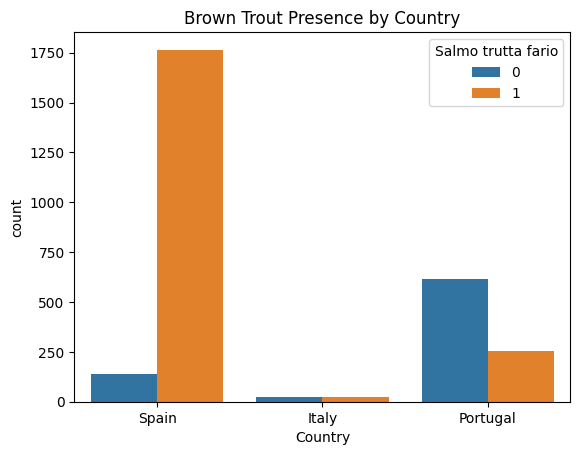

In [99]:
#visualization
sns.countplot(
    x="Country",
    hue="Salmo trutta fario",
    data=df2
)

plt.title("Brown Trout Presence by Country")
plt.show()

The presence of brown trout was assessed in terms of independence from a location through a chi-square test, which resulted in a statistically significant association (p-value = 7.31×10^-265), thereby rejecting the null hypothesis of independence. This shows that brown trout presence and absence is not uniformly distributed across different countries.

##4. Elevation differences (top 8 catchments)

**Hypothesis**

- H0: Mean elevation is equal across catchments

In [100]:
#select top 8
top8 = df2["Catchment_name"].value_counts().head(8).index
df_top8 = df2[df2["Catchment_name"].isin(top8)]

In [101]:
#homogeneity of variances check (Levene test)
groups = [
    df_top8[df_top8["Catchment_name"] == c]["Elevation_mean_catch"]
    for c in top8
]

stat, p_lev_anova = sts.levene(*groups)
print("Levene ANOVA p-value:", p_lev_anova)

Levene ANOVA p-value: 4.6335146163528704e-86


In [102]:
#ANOVA
f_stat, p_anova = sts.f_oneway(*groups)
print("ANOVA p-value:", p_anova)

ANOVA p-value: 3.9710096360208786e-193


In [103]:
#post-hoc test (Tukey)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_top8["Elevation_mean_catch"],
    groups=df_top8["Catchment_name"],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica        Douro   113.406 0.0002   37.6078  189.2042   True
  Cantabrica Galiza-Norte -219.0555    0.0 -280.5173 -157.5936   True
  Cantabrica   Galiza-Sul   32.9023 0.9841   -75.407  141.2115  False
  Cantabrica       Guadia -330.6163    0.0 -435.9711 -225.2614   True
  Cantabrica        Minho  258.0052    0.0  196.4999  319.5105   True
  Cantabrica      Mondego  -40.3519 0.9597 -153.0173   72.3134  False
  Cantabrica         Tejo -202.1506    0.0  -281.215 -123.0862   True
       Douro Galiza-Norte -332.4615    0.0 -399.2247 -265.6983   True
       Douro   Galiza-Sul  -80.5038 0.3568 -191.9068   30.8993  False
       Douro       Guadia -444.0223    0.0 -552.5552 -335.4893   True
       Douro        Minho  144.5992    0.0    77.796  211.4023   True
       Douro      Mo

One-Way ANOVA was used to test for elevation differences between eight of the most sampled catchments, and Levene's test was conducted to evaluate the assumption of homogeneity of variance, revealing a violation (p-value = 4.63×10^-86). Nonetheless, the ANOVA results demonstrated highly significant differences between catchments (p-value = 3.97×10^-193), allowing the null hypothesis to be rejected.

Tukey’s post-hoc analysis of pairwise comparisons then revealed relatively extensive statistically significant differences between most pairwise comparisons. However, statistically insignificant differences could be found between certain pairs (Cantabrica–Galiza-Sul; Cantabrica–Mondego; Douro–Galiza-Sul; Galiza-Norte–Tejo; Galiza-Sul–Mondego). Collectively, these findings demonstrate that elevation differs considerably across catchments. However, groups may share relatively similar mean elevation values.

##5. Non-parametric equivalent (Kruskal-Wallis)

**Hypothesis**

- H0: Distribution of elevation is the same across catchments

In [104]:
h_stat, p_kw = sts.kruskal(*groups)
print("Kruskal-Wallis p-value:", p_kw)

Kruskal-Wallis p-value: 1.5742212761017362e-175


Given that ANOVA assumptions may have been violated, a Kruskal-Wallis test was used as an alternative (non-parametric). Kruskal-Wallis indicated extremely significant differences between catchments (p-value = 1.57×10^-175), and rejected the null hypothesis that all groups had the same distribution.

Results were consistent between ANOVA and Kruskal-Wallis, strengthening the robustness of our conclusions; the observed differences between elevations of catchments was statistically valid despite the violation of parametric assumptions.

####**Conclusion:**

The consistency of results across multiple statistical approaches highlights the robustness of the findings and supports the validity of the conclusions drawn from the data.